In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [105]:
import pandas as pd
import io

def read_horizons_csv(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()

    # 1. Find the markers and the header line
    # Usually, the column names are on the line before the '****************' that precedes $$SOE
    # For this specific file, the names are at line index 73
    soe_idx = next(i for i, line in enumerate(lines) if "$$SOE" in line)
    eoe_idx = next(i for i, line in enumerate(lines) if "$$EOE" in line)
    
    # Extract the header names (found just above the data)
    header_line = lines[soe_idx - 2].strip()
    columns = [col.strip() for col in header_line.split(',')]
    
    # Handle the "unnamed" flag columns (N, A, m, etc.)
    columns = [c if c else f"Flag_{i}" for i, c in enumerate(columns)]

    # 2. Extract only the data lines
    data_lines = lines[soe_idx + 1 : eoe_idx]
    
    # 3. Load into Pandas
    df = pd.read_csv(io.StringIO("".join(data_lines)), names=columns, header=None)
    return df

# Usage
df = read_horizons_csv('horizons_results_2001_EC_csv.txt')
print(df.head())

print(df[['Date_________JDUT', 'r', 'delta']].head())

   Date_________JDUT Flag_1 Flag_2   R.A._(ICRF)   DEC__(ICRF)  dRA*cosD  \
0       2.461092e+06      N      m   15 44 14.20   -22 16 40.3  -1063.34   
1       2.461092e+06      N      m   15 44 01.44   -22 16 02.2  -1063.37   
2       2.461092e+06      A      m   15 43 48.68   -22 15 24.1  -1063.44   
3       2.461092e+06      A      m   15 43 35.92   -22 14 46.0  -1063.56   
4       2.461092e+06      A      m   15 43 23.15   -22 14 07.9  -1063.71   

   d(DEC)/dt    a-mass   mag_ex   APmag    S-brt         r       rdot  \
0   226.3277      n.a.     n.a.  16.171     n.a.  0.995355  21.873548   
1   226.2696      n.a.     n.a.  16.169     n.a.  0.995443  21.873835   
2   226.2193      n.a.     n.a.  16.167     n.a.  0.995531  21.874121   
3   226.1773      n.a.     n.a.  16.166     n.a.  0.995618  21.874407   
4   226.1446      n.a.     n.a.  16.164     n.a.  0.995706  21.874693   

      delta    deldot    S-T-O  T-O-M  MN_Illu%  Flag_18  
0  0.083735  3.184396  83.0578  122.8    7.03

In [106]:
dates = df["Date_________JDUT"].astype(float).to_numpy()

dates -= 2400000


In [155]:
night = '26_03_01_b/'

df_data = pd.read_csv(
            night + 'pipelineout_datasubset.dat', sep="\t", comment="#",
            names=["index", "Label", "J.D.-2400000", "rel_flux_T1", "rel_flux_err_T1",
                   "AIRMASS", "Source-Sky_T1", "Source_Error_T1"])

print(df_data['J.D.-2400000'].to_numpy())

dates_observ = df_data['J.D.-2400000'].to_numpy()

[61101.780573 61101.781055 61101.781563 61101.78204  61101.782517
 61101.783016 61101.783493 61101.783991 61101.784469 61101.784968
 61101.785445 61101.785924 61101.786432 61101.786911 61101.787412
 61101.787911 61101.788389 61101.788868 61101.789347 61101.789857
 61101.790356 61101.790833 61101.791331 61101.791808 61101.792288
 61101.792765 61101.793245 61101.793745 61101.794223 61101.794731
 61101.795208 61101.795686 61101.796165 61101.796642 61101.797127
 61101.797608 61101.798086 61101.798563 61101.799075 61101.799586
 61101.800065 61101.800544 61101.801044 61101.801524 61101.802002
 61101.802503 61101.803006 61101.803484 61101.80397  61101.804475
 61101.804953 61101.805453 61101.805931 61101.806408 61101.806907
 61101.807384 61101.807869 61101.808346 61101.808824 61101.809333
 61101.809811 61101.810296 61101.810774 61101.811273 61101.81175
 61101.812228 61101.812727 61101.813227 61101.813704 61101.814214
 61101.814691 61101.81517  61101.815669 61101.816147 61101.816623
 61101.8171

In [156]:
d_min = np.min(dates_observ)
d_max = np.max(dates_observ)

mask = (dates >= d_min - 0.5) & (dates <= d_max + 0.5)

new_r = np.interp(dates_observ, dates[mask], df["r"][mask])
new_delta = np.interp(dates_observ, dates[mask], df["delta"][mask])


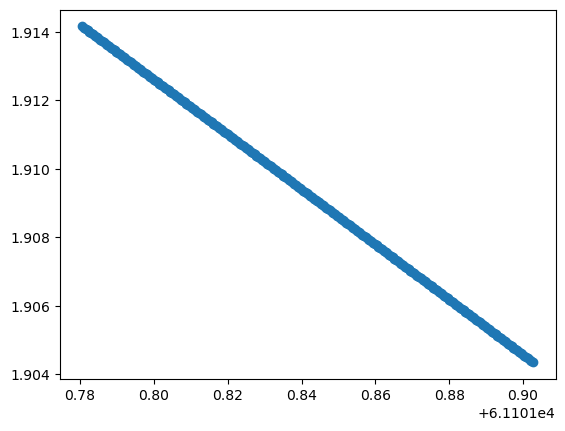

In [157]:
# see page 549-550
correction = -2.5*np.log10(new_r*new_delta)

plt.scatter(dates_observ, correction)
plt.show()

In [158]:
data = np.column_stack((dates_observ, correction))
df_out = pd.DataFrame({
    "Date_________JDUT": dates_observ,
    "mag_correction": correction
})

df_out.to_csv(night + "mag_correction.dat", sep="\t")
